# 01 — Data Preparation: Layer 4 (Stance & Sarcasm) Classifier

| | |
|---|---|
| **Project** | Public Pulse |
| **Pipeline stage** | Layer 4 — Pragmatic Stance & Sarcasm |
| **Notebook role** | Data preparation, language preprocessing, column scoping, class imbalance mitigation |
| **Owner** | Thrithwaka |
| **Environment** | Google Colab, project files on Google Drive |
| **Upstream input** | `data/golden_sample/golden_sample_labeled.csv` |
| **Downstream consumers** | `02_training.ipynb`, `03_evaluation.ipynb` |
| **Random seed** | 42 |

## Purpose

Same two corrections as the Layer 2 notebook: genuine Sinhala/Singlish/English-aware
text preprocessing (`text_clean`), and an explicit, auditable column-scoping allowlist
answering directly which columns from Layers 1/2/3 this layer actually needs (short
answer: Layer 1 as a filter only, nothing from Layers 2/3).

## How to Read This Notebook

No claim of 100% accuracy is made anywhere in this pipeline.

## 1. Google Colab Setup — Environment & Google Drive

In [ ]:
!pip uninstall -y torchvision torchaudio -q
!pip install -q transformers==4.53.0 datasets accelerate sentencepiece "scikit-learn>=1.4"
print("Install complete. REQUIRED NEXT STEP: Runtime -> Restart session, then Runtime -> Run all.")

Install complete. REQUIRED NEXT STEP: Runtime -> Restart session, then Runtime -> Run all.


**Stop here and restart the runtime now**, then **Runtime → Run all**.

In [ ]:
import transformers
print("transformers:", transformers.__version__)
assert transformers.__version__ == "4.53.0", "Did you Restart session after the install cell?"
print("Environment verified.")

transformers: 4.53.0
Environment verified.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
PROJECT_ROOT = Path("/content/drive/MyDrive/public-pulse-srilanka")
assert PROJECT_ROOT.exists(), f"Project folder not found at {PROJECT_ROOT}."
print("Project root:", PROJECT_ROOT.resolve())

Mounted at /content/drive
Project root: /content/drive/MyDrive/public-pulse-srilanka


In [ ]:
golden_check = PROJECT_ROOT / "data" / "golden_sample" / "golden_sample_labeled.csv"
print("Golden sample exists:", golden_check.exists())

Golden sample exists: True


## 2. Setup & Configuration

In [ ]:
import json
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

GOLDEN_SAMPLE_PATH = PROJECT_ROOT / "data" / "golden_sample" / "golden_sample_labeled.csv"
SPLITS_DIR = PROJECT_ROOT / "data" / "splits" / "layer4"
MODEL_DIR = PROJECT_ROOT / "models" / "layer4_stance"
RESULTS_DIR = PROJECT_ROOT / "results" / "eda"
SPLITS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

UNRELIABLE_ANNOTATOR = "llm_groq_openai/gpt-oss-120b"
OVERSAMPLE_FLOOR = 500
OVERSAMPLE_MAX_MULTIPLIER = 3

print("Golden sample path:", GOLDEN_SAMPLE_PATH.resolve())

Golden sample path: /content/drive/MyDrive/public-pulse-srilanka/data/golden_sample/golden_sample_labeled.csv


## 3. Load the Golden Sample

In [ ]:
df = pd.read_csv(GOLDEN_SAMPLE_PATH)
print("Raw golden sample shape:", df.shape)

Raw golden sample shape: (10000, 28)


## 4. Data Cleaning

In [ ]:
before_n = len(df)
df_clean = df[df["annotator_id"] != UNRELIABLE_ANNOTATOR].copy()
print(f"Removed unreliable annotator batch: {before_n} -> {len(df_clean)} rows")

Removed unreliable annotator batch: 10000 -> 9290 rows


## 5. Column Scoping for Layer 4 — Explicit Allowlist

**Directly answers: do I need Layer 1/2/3 columns when fine-tuning Layer 4?**

- **Layer 1: filter only, dropped after use** — same reasoning as Layer 2.
- **Layer 2, Layer 3: not needed at all.** Layer 4 (stance/sarcasm) is independent of
  topic — a comment gets a stance regardless of what topic it's about, or whether it has
  one. Including these would imply a dependency that doesn't exist in this taxonomy.
- **`is_sarcastic`: kept, but ONLY as a diagnostic/consistency-check column, explicitly
  never as a model feature.** It is a near-perfect proxy for part of the target label
  (`STANCE_CRIT_SARC`, prior to merging) — including it as an input feature would let the
  model trivially read the answer rather than learn from text. It's dropped from the
  feature set at the same point Layer 2/3 are dropped, immediately after this check.

In [ ]:
valid_df = df_clean[df_clean["layer1_utility_label"] == "VALID"].copy()
print(f"Valid rows: {len(valid_df)} / {len(df_clean)}")

# is_sarcastic consistency check -- done here, BEFORE it's excluded from the modeling frame
consistency = pd.crosstab(valid_df["is_sarcastic"], valid_df["layer4_stance_label"])
print("\nis_sarcastic vs layer4_stance_label (pre-merge):")
print(consistency)

LAYER4_ALLOWED_COLUMNS = [
    "comment_id", "channel_name", "source_type", "text_raw",
    "language_detected", "message_length", "emoji_list",
    "layer4_stance_label",   # the target for this notebook
]

dropped_columns = set(valid_df.columns) - set(LAYER4_ALLOWED_COLUMNS)
print(f"\nColumns kept ({len(LAYER4_ALLOWED_COLUMNS)}): {LAYER4_ALLOWED_COLUMNS}")
print(f"Columns dropped ({len(dropped_columns)}), including layer1/2/3 and is_sarcastic: {sorted(dropped_columns)}")

valid_df = valid_df[LAYER4_ALLOWED_COLUMNS].copy()

assert "layer1_utility_label" not in valid_df.columns
assert "layer2_topic_label" not in valid_df.columns
assert "layer3_subissue_label" not in valid_df.columns
assert "is_sarcastic" not in valid_df.columns, "is_sarcastic must not be a feature -- leakage risk"
print("\nColumn scoping verified.")

Valid rows: 7686 / 9290

is_sarcastic vs layer4_stance_label (pre-merge):
layer4_stance_label  STANCE_CRIT_DIR  STANCE_CRIT_SARC  STANCE_NEUT  STANCE_SUPP
is_sarcastic                                                                    
False                           5264                 0         1957          305
True                               0               160            0            0

Columns kept (8): ['comment_id', 'channel_name', 'source_type', 'text_raw', 'language_detected', 'message_length', 'emoji_list', 'layer4_stance_label']
Columns dropped (20), including layer1/2/3 and is_sarcastic: ['annotation_notes', 'annotator_id', 'author_broadcast_msg_count', 'author_hash', 'broadcast_id', 'duplicate_group_id', 'is_duplicate_text', 'is_flooding_spam', 'is_member', 'is_reply', 'is_sarcastic', 'is_super_chat', 'layer1_utility_label', 'layer2_topic_label', 'layer3_subissue_label', 'length_bucket', 'parent_comment_id', 'published_at', 'strata_key', 'text_normalized']

Column sco

### 5.1 Confirm `NULL` Has Zero Examples

In [ ]:
null_count = valid_df["layer4_stance_label"].isna().sum()
print(f"Blank/NULL layer4_stance_label: {null_count} / {len(valid_df)}")
if null_count == 0:
    print("FINDING: Zero NULL examples -- excluded from the trainable label set.")

Blank/NULL layer4_stance_label: 0 / 7686
FINDING: Zero NULL examples -- excluded from the trainable label set.


## 6. Language-Aware Text Preprocessing (Sinhala / Singlish / English)

Same `text_clean` construction as Layer 2 — Unicode NFC normalization (critical for
Sinhala's combining-mark variability), zero-width character removal, URL placeholder,
whitespace collapsing. **No lowercasing/punctuation stripping** — this matters more for
Layer 4 than any other layer, since punctuation and emoji patterns (`!!!`, contrastive
emoji use) are plausible sarcasm signals that aggressive normalization would destroy.

**Engineering note:** identical logic to Layer 2's `clean_text()`. This duplication is a
known, acceptable trade-off for notebook self-containment — it should be refactored into
`src/public_pulse/preprocessing/text_cleaning.py` and imported by both layers'
notebooks so a future change to cleaning logic doesn't need to be made twice.

In [ ]:
ZERO_WIDTH_PATTERN = re.compile(r"[\u200b\u200c\u200d\ufeff]")
WHITESPACE_PATTERN = re.compile(r"\s+")
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = unicodedata.normalize("NFC", text)
    text = ZERO_WIDTH_PATTERN.sub("", text)
    text = URL_PATTERN.sub("[URL]", text)
    text = WHITESPACE_PATTERN.sub(" ", text).strip()
    return text

valid_df["text_clean"] = valid_df["text_raw"].apply(clean_text)
changed = valid_df[valid_df["text_raw"] != valid_df["text_clean"]]
print(f"Rows changed by cleaning: {len(changed)} / {len(valid_df)} ({len(changed)/len(valid_df)*100:.1f}%)")

Rows changed by cleaning: 2128 / 7686 (27.7%)


**Decision: `text_clean` is the model input for Layer 4**, superseding the plain `text_raw` choice used in an earlier version.

## 7. Feature Engineering — Stance & Sarcasm Diagnostics

In [ ]:
SINHALA_RANGE = re.compile(r"[\u0D80-\u0DFF]")
LATIN_RANGE = re.compile(r"[A-Za-z]")
POSITIVE_EMOJI = {"👏", "😂", "❤️", "😍", "🥰", "👍", "😊", "🙌"}

def script_composition(text):
    if not isinstance(text, str) or len(text) == 0:
        return 0.0, 0.0, False
    s = len(SINHALA_RANGE.findall(text)); l = len(LATIN_RANGE.findall(text))
    total = s + l
    if total == 0:
        return 0.0, 0.0, False
    sr, lr = s/total, l/total
    return round(sr,3), round(lr,3), (sr>0.1 and lr>0.1)

def has_positive_emoji(text):
    return isinstance(text, str) and any(e in text for e in POSITIVE_EMOJI)

feats = valid_df["text_clean"].apply(script_composition)
valid_df["sinhala_char_ratio"] = feats.apply(lambda x: x[0])
valid_df["latin_char_ratio"] = feats.apply(lambda x: x[1])
valid_df["is_code_switched"] = feats.apply(lambda x: x[2])
valid_df["has_positive_emoji"] = valid_df["text_clean"].apply(has_positive_emoji)
valid_df["emoji_count"] = valid_df["emoji_list"].apply(lambda x: 0 if pd.isna(x) else len(str(x).split(",")))

print("Code-switching rate:", f"{valid_df['is_code_switched'].mean()*100:.1f}%")
print("Positive-emoji comments:", valid_df["has_positive_emoji"].sum())

Code-switching rate: 7.2%
Positive-emoji comments: 1097


layer4_stance_label
STANCE_CRIT_SARC    71.2
STANCE_NEUT         13.9
STANCE_CRIT_DIR     12.8
STANCE_SUPP         11.8
Name: has_positive_emoji, dtype: float64


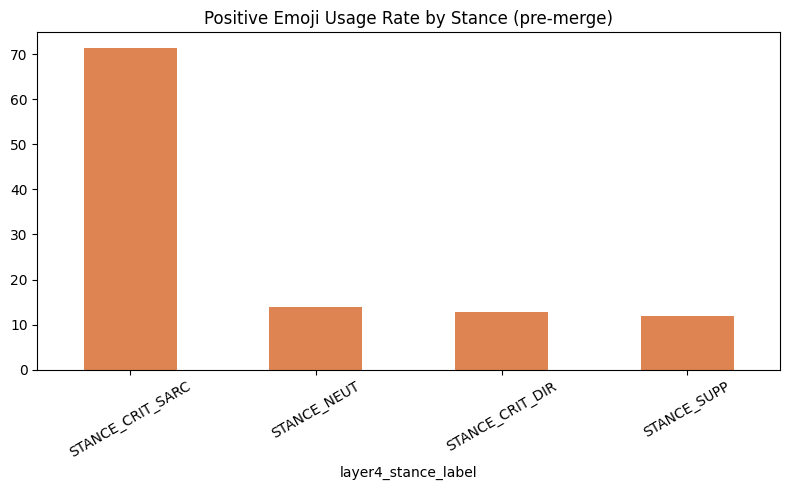

In [ ]:
emoji_by_stance = valid_df.groupby("layer4_stance_label")["has_positive_emoji"].mean().sort_values(ascending=False) * 100
print(emoji_by_stance.round(1))

fig, ax = plt.subplots(figsize=(8, 5))
emoji_by_stance.plot(kind="bar", ax=ax, color="#DD8452")
ax.set_title("Positive Emoji Usage Rate by Stance (pre-merge)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "layer4_positive_emoji_by_stance.png", dpi=150)
plt.show()

## 8. Layer 4 Target Variable Analysis

In [ ]:
l4_counts = valid_df["layer4_stance_label"].value_counts()
print(pd.DataFrame({"count": l4_counts, "percent": (l4_counts/len(valid_df)*100).round(1)}))

                     count  percent
layer4_stance_label                
STANCE_CRIT_DIR       5264     68.5
STANCE_NEUT           1957     25.5
STANCE_SUPP            305      4.0
STANCE_CRIT_SARC       160      2.1


## 9. Merge Rare Classes — Documented Scope Decision

`STANCE_CRIT_SARC` (160, 92.5% single-annotator concentration) merged into
`STANCE_CRIT_DIR` → `STANCE_CRIT`. The direct/sarcastic distinction is deferred to v2.
Original labels preserved for traceability, and remain checkable via the
`is_sarcastic`-vs-label crosstab already printed in Section 5.

In [ ]:
MERGE_MAP = {"STANCE_CRIT_SARC": "STANCE_CRIT", "STANCE_CRIT_DIR": "STANCE_CRIT"}

valid_df["layer4_stance_label_original"] = valid_df["layer4_stance_label"]
valid_df["layer4_stance_label"] = valid_df["layer4_stance_label"].replace(MERGE_MAP)

print(valid_df["layer4_stance_label"].value_counts())
print(f"Classes: {valid_df['layer4_stance_label'].nunique()}")

layer4_stance_label
STANCE_CRIT    5424
STANCE_NEUT    1957
STANCE_SUPP     305
Name: count, dtype: int64
Classes: 3


## 10. Class Balance Assessment

In [ ]:
FLOOR, TARGET = 500, 1000
l4_counts_merged = valid_df["layer4_stance_label"].value_counts()
assessment = pd.DataFrame({"count": l4_counts_merged})
assessment["meets_floor"] = assessment["count"] >= FLOOR
assessment["meets_target"] = assessment["count"] >= TARGET
print(assessment)

                     count  meets_floor  meets_target
layer4_stance_label                                  
STANCE_CRIT           5424         True          True
STANCE_NEUT           1957         True          True
STANCE_SUPP            305        False         False


## 11. Stratified Train / Validation / Test Split

Split first, mitigate second — same non-negotiable ordering as Layer 2.

In [ ]:
feature_cols = ["comment_id", "text_raw", "text_clean", "channel_name", "source_type",
                "language_detected", "sinhala_char_ratio", "latin_char_ratio",
                "is_code_switched", "has_positive_emoji", "emoji_count"]
# is_sarcastic already excluded at Section 5 -- never reaches this feature list at all

X = valid_df[feature_cols]
y = valid_df["layer4_stance_label"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

train_df = X_train.copy(); train_df["layer4_stance_label"] = y_train
val_df = X_val.copy(); val_df["layer4_stance_label"] = y_val
test_df = X_test.copy(); test_df["layer4_stance_label"] = y_test

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
print(train_df["layer4_stance_label"].value_counts())

Train: 5380  Val: 1153  Test: 1153
layer4_stance_label
STANCE_CRIT    3797
STANCE_NEUT    1370
STANCE_SUPP     213
Name: count, dtype: int64


## 12. Class Imbalance Mitigation

In [ ]:
def compute_oversample_target(n, floor, mult):
    return n if n >= floor else min(floor, n * mult)

train_counts = train_df["layer4_stance_label"].value_counts()
plan = pd.DataFrame({"original_count": train_counts})
plan["target_count"] = plan["original_count"].apply(lambda n: compute_oversample_target(n, OVERSAMPLE_FLOOR, OVERSAMPLE_MAX_MULTIPLIER))
print(plan)

                     original_count  target_count
layer4_stance_label                              
STANCE_CRIT                    3797          3797
STANCE_NEUT                    1370          1370
STANCE_SUPP                     213           500


In [ ]:
parts = [train_df]
for stance, row in plan.iterrows():
    extra_needed = int(row["target_count"] - row["original_count"])
    if extra_needed > 0:
        pool = train_df[train_df["layer4_stance_label"] == stance]
        parts.append(pool.sample(n=extra_needed, replace=True, random_state=RANDOM_STATE))

train_oversampled_df = pd.concat(parts, ignore_index=True).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print("Before:", len(train_df), " After:", len(train_oversampled_df))
print(train_oversampled_df["layer4_stance_label"].value_counts())

Before: 5380  After: 5667
layer4_stance_label
STANCE_CRIT    3797
STANCE_NEUT    1370
STANCE_SUPP     500
Name: count, dtype: int64


In [ ]:
STANCE_LABELS = sorted(train_oversampled_df["layer4_stance_label"].unique())
weights_arr = compute_class_weight(class_weight="balanced", classes=np.array(STANCE_LABELS), y=train_oversampled_df["layer4_stance_label"].values)
class_weights_dict = dict(zip(STANCE_LABELS, weights_arr.round(4)))
print(class_weights_dict)

with open(MODEL_DIR / "class_weights.json", "w") as f:
    json.dump(class_weights_dict, f, indent=2)

{'STANCE_CRIT': np.float64(0.4975), 'STANCE_NEUT': np.float64(1.3788), 'STANCE_SUPP': np.float64(3.778)}


## 13. Data Quality Validation

In [ ]:
errors = []
for name, sdf in [("train", train_oversampled_df), ("val", val_df), ("test", test_df)]:
    if sdf["layer4_stance_label"].isna().any():
        errors.append(f"{name}: missing labels")
    invalid = set(sdf["layer4_stance_label"].unique()) - set(STANCE_LABELS)
    if invalid:
        errors.append(f"{name}: unexpected labels {invalid}")
    for leaked_col in ["layer1_utility_label", "layer2_topic_label", "layer3_subissue_label", "is_sarcastic"]:
        if leaked_col in sdf.columns:
            errors.append(f"{name}: {leaked_col} leaked into Layer 4 data")

val_test_ids = set(val_df["comment_id"]) | set(test_df["comment_id"])
if val_test_ids & set(train_oversampled_df["comment_id"]):
    errors.append("LEAKAGE between train and val/test")

if errors:
    for e in errors: print("FAIL:", e)
    raise ValueError("Data quality checks failed.")
print("All checks passed: labels valid, no cross-layer column leakage, no is_sarcastic leakage, no train/val/test leakage.")

All checks passed: labels valid, no cross-layer column leakage, no is_sarcastic leakage, no train/val/test leakage.


## 14. Save Splits

In [ ]:
train_oversampled_df.to_csv(SPLITS_DIR / "train.csv", index=False)
val_df.to_csv(SPLITS_DIR / "val.csv", index=False)
test_df.to_csv(SPLITS_DIR / "test.csv", index=False)
print("Saved to", SPLITS_DIR.resolve())

Saved to /content/drive/MyDrive/public-pulse-srilanka/data/splits/layer4


## 15. Tokenizer Compatibility Check (on `text_clean`)

In [ ]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
MAX_SEQ_LENGTH = 256
token_lengths = train_oversampled_df["text_clean"].apply(lambda t: len(tokenizer.tokenize(str(t))))
print(f"% exceeding {MAX_SEQ_LENGTH}: {(token_lengths > MAX_SEQ_LENGTH).mean()*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (589 > 512). Running this sequence through the model will result in indexing errors


% exceeding 256: 0.56%


## 16. Notebook Summary

### What changed from the earlier version
1. Added `text_clean` (Unicode NFC + zero-width removal + URL placeholder + whitespace collapse)
2. Added explicit column-scoping allowlist (Section 5) with hard assertions, directly
   answering whether Layer 1/2/3 columns are needed (no, except Layer 1 as a filter)
3. `is_sarcastic` consistency check now happens explicitly *before* exclusion, so the
   diagnostic value isn't lost even though it's dropped from the modeling frame

## 17. Handover Notes — For `02_training.ipynb`

**Model input column is now `text_clean`**, not `text_raw` — update the tokenization step.

**Label set:** 3 classes (`STANCE_CRIT` merged). `num_labels=3`.

**`is_sarcastic` is guaranteed absent** from these splits (Section 5 assertion) —
no further exclusion logic needed downstream.

**Class weights:** `models/layer4_stance/class_weights.json`, already post-oversampling.